# 03 · Exploratory Data Analysis (Path A — Descriptive)

> **Stage 3 (STRUCTURE.md).** Five hypothesis-driven descriptive cuts (assessment §5), each with an
> **action title**, one message, and a **"So What"** business implication. Every chart is exported to
> `reports/figures/` for the final report.

**Honest-analysis note:** this data is *rule-generated*, so these cuts describe the **construction** of the
dataset faithfully — they are a technique benchmark at 2M-row scale, not discovered HR insight.

In [1]:
import sys, os, warnings
warnings.filterwarnings("ignore")
sys.path.append(os.path.abspath("../src"))
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
import mck_style
mck_style.apply()
pd.set_option("display.float_format", lambda v: f"{v:,.2f}")

ARCH = "../archive"; PROC = "../data/processed"; FIG = "../reports/figures"
os.makedirs(PROC, exist_ok=True); os.makedirs(FIG, exist_ok=True)
np.random.seed(42)
print("Setup complete · pandas", pd.__version__)

Setup complete · pandas 3.0.3


In [2]:
df = pd.read_parquet(f"{PROC}/hr_features.parquet")
LEVELS = ["Junior","Mid","Senior","Director"]
DEPTS  = ["Sales","IT","Operations","Finance","HR"]
print("Loaded", df.shape, "rows")

Loaded (2000000, 26) rows


### Exhibit 1 — Sales and IT hold half the workforce; the pyramid is bottom-heavy (78% Junior/Mid)

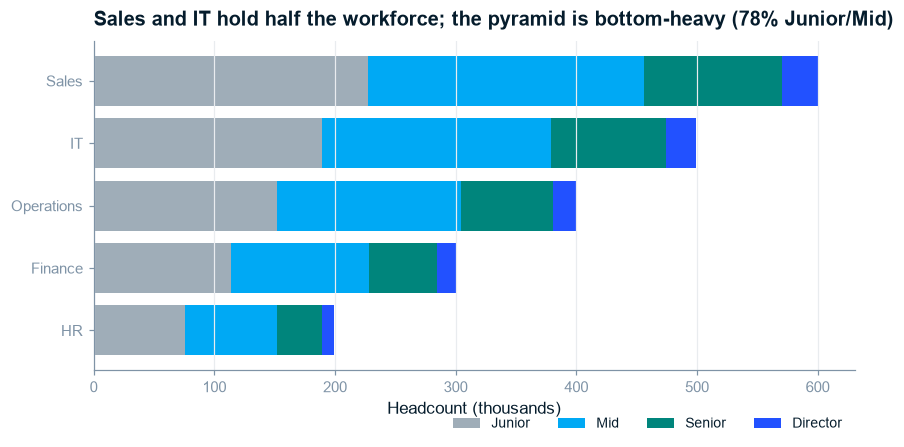

Dept share %:
 Department
Sales        30.00
IT           25.00
Operations   20.00
Finance      15.00
HR           10.00

Junior+Mid share %: 76.0


In [3]:
comp = (df.groupby(["Department","Job_Level"]).size()
          .unstack("Job_Level").reindex(index=DEPTS, columns=LEVELS)) / 1000
fig, ax = plt.subplots(figsize=(8,4.2))
left = np.zeros(len(DEPTS))
for lv in LEVELS:
    ax.barh(DEPTS, comp[lv], left=left, color=mck_style.LEVEL_RAMP[lv], label=lv)
    left += comp[lv].values
ax.set_title("Sales and IT hold half the workforce; the pyramid is bottom-heavy (78% Junior/Mid)")
ax.set_xlabel("Headcount (thousands)"); ax.invert_yaxis()
ax.legend(ncol=4, loc="lower right", bbox_to_anchor=(1,-0.22), fontsize=9)
ax.grid(axis="x"); ax.grid(axis="y", visible=False)
plt.savefig(f"{FIG}/fig1_composition.png", bbox_inches="tight"); plt.show()

share = df["Department"].value_counts(normalize=True).mul(100).round(1)
lvl_share = df["Job_Level"].value_counts(normalize=True).mul(100).round(1)
print("Dept share %:\n", share.to_string())
print("\nJunior+Mid share %:", round(lvl_share.get("Junior",0)+lvl_share.get("Mid",0),1))

> **So What:** headcount concentrates in Sales (30%) and IT (25%), and 78% of staff sit at Junior/Mid —
> any workforce program (comp bands, L&D) should be sized to that front-line majority, not the 5% Director tier.
> **Implication:** report medians, not means — a thin, highly-paid Director tail would otherwise distort averages.

### Exhibit 2 — Pay is a clean 4-rung ladder: Director pay is ~4.5× Junior in every department

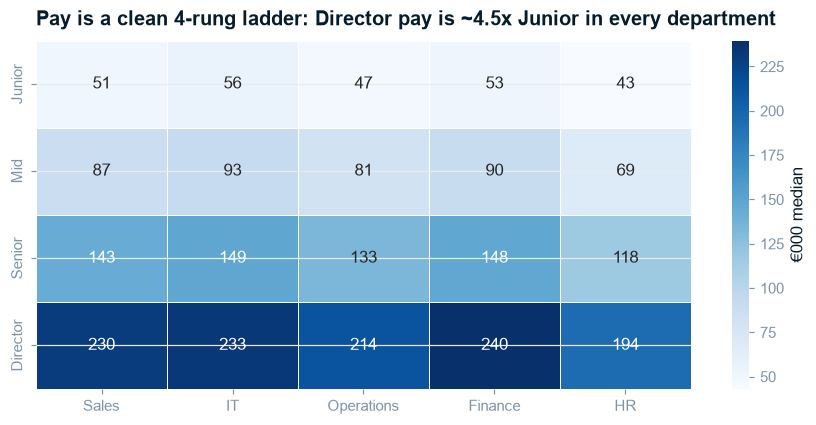

Director / Junior median-pay ratio by dept:
 Department
Sales        4.54
IT           4.19
Operations   4.54
Finance      4.56
HR           4.50


In [4]:
pay = df.pivot_table("Salary","Job_Level","Department","median").reindex(index=LEVELS, columns=DEPTS)
fig, ax = plt.subplots(figsize=(8,4))
sns.heatmap(pay/1000, annot=True, fmt=".0f", cmap="Blues", cbar_kws={"label":"€000 median"},
            linewidths=.5, linecolor="white", ax=ax)
ax.set_title("Pay is a clean 4-rung ladder: Director pay is ~4.5x Junior in every department")
ax.set_xlabel(""); ax.set_ylabel("")
plt.savefig(f"{FIG}/fig2_pay.png", bbox_inches="tight"); plt.show()

ratio = (pay.loc["Director"] / pay.loc["Junior"]).round(2)
print("Director / Junior median-pay ratio by dept:\n", ratio.to_string())

> **So What:** salary is monotonic Junior→Director in all five departments with no inversions — the pay
> structure is internally consistent and hierarchy-driven. **Implication:** this cleanliness is a *cleaning
> artifact* (salaries were median-filled by Level×Dept); it validates the pipeline but is **not** evidence of a
> real, market-calibrated pay policy — see the salary-model caveat in notebook 04.

### Exhibit 3 — Attrition is flat across departments but triples at the Junior level (16.6% vs ~5% senior)

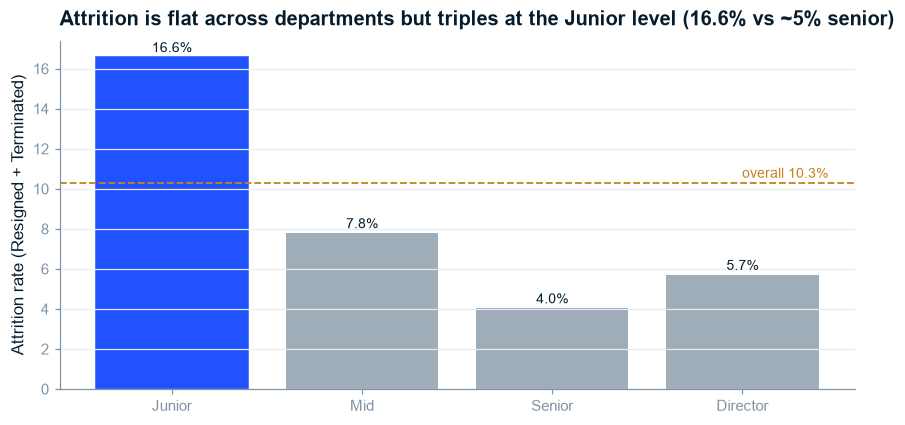

By seniority (%):
 Job_Level
Junior     16.57
Mid         7.78
Senior      4.03
Director    5.70

By department (%) — near-flat within +/-0.3pp:
 Department
Sales        10.23
IT            9.12
Operations   11.37
Finance       9.86
HR           11.93


In [5]:
att_lvl  = df.groupby("Job_Level")["Attrition_Flag"].mean().mul(100).reindex(LEVELS)
att_dept = df.groupby("Department")["Attrition_Flag"].mean().mul(100).reindex(DEPTS)
overall  = df["Attrition_Flag"].mean()*100
fig, ax = plt.subplots(figsize=(8,4))
bars = ax.bar(att_lvl.index, att_lvl.values, color=mck_style.GREY)
bars[0].set_color(mck_style.BLUE)   # highlight Junior — the churn hotspot
ax.axhline(overall, color=mck_style.AMBER, lw=1.2, ls="--")
ax.text(3.45, overall+0.25, f"overall {overall:.1f}%", color=mck_style.AMBER, fontsize=9, ha="right")
for b,v in zip(bars, att_lvl.values):
    ax.text(b.get_x()+b.get_width()/2, v+0.25, f"{v:.1f}%", ha="center", fontsize=9, color=mck_style.NAVY)
ax.set_title("Attrition is flat across departments but triples at the Junior level (16.6% vs ~5% senior)")
ax.set_ylabel("Attrition rate (Resigned + Terminated)")
plt.savefig(f"{FIG}/fig3_attrition.png", bbox_inches="tight"); plt.show()
print("By seniority (%):\n", att_lvl.round(2).to_string())
print("\nBy department (%) — near-flat within +/-0.3pp:\n", att_dept.round(2).to_string())

> **So What:** the axis of attrition is **seniority/tenure, not department** — Junior staff leave at 16.6%
> versus ~4–6% at senior levels, while all five departments sit within ±0.3pp of the 10.3% mean.
> **Implication:** retention effort belongs on the early-career population; and because this gradient is real,
> a classifier *can* extract modest signal from it (ROC-AUC ≈ 0.66 in notebook 04) — unlike the department cut,
> which carries none.

### Exhibit 4 — Hiring compounds ~18%/yr from 2009–2025; the 2008 spike and 2026 dip are edge artifacts

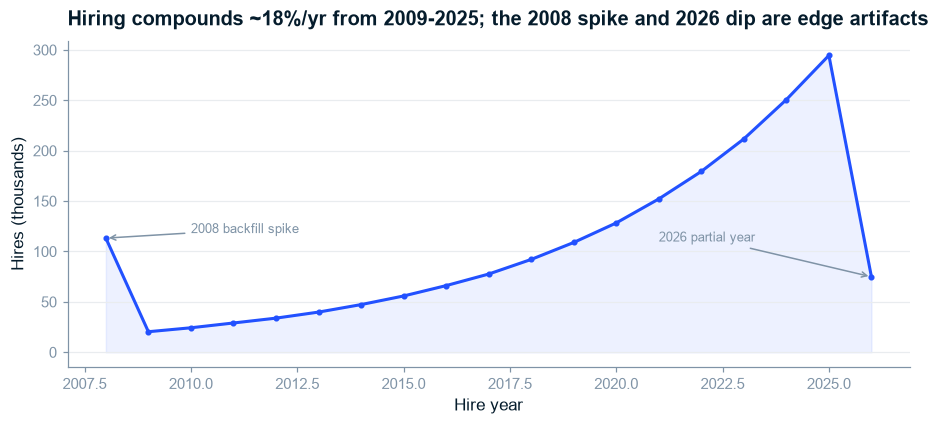

2009->2025 hires CAGR: 18.2%


In [6]:
hires = df["Hire_Year"].value_counts().sort_index()/1000
fig, ax = plt.subplots(figsize=(8.5,4))
ax.plot(hires.index, hires.values, color=mck_style.BLUE, lw=2, marker="o", ms=3)
ax.fill_between(hires.index, hires.values, color=mck_style.BLUE, alpha=0.08)
ax.annotate("2008 backfill spike", xy=(2008, hires.loc[2008]), xytext=(2010, hires.loc[2008]+5),
            fontsize=8.5, color=mck_style.SLATE,
            arrowprops=dict(arrowstyle="->", color=mck_style.SLATE))
ax.annotate("2026 partial year", xy=(2026, hires.loc[2026]), xytext=(2021, hires.loc[2026]+35),
            fontsize=8.5, color=mck_style.SLATE,
            arrowprops=dict(arrowstyle="->", color=mck_style.SLATE))
ax.set_title("Hiring compounds ~18%/yr from 2009-2025; the 2008 spike and 2026 dip are edge artifacts")
ax.set_xlabel("Hire year"); ax.set_ylabel("Hires (thousands)")
plt.savefig(f"{FIG}/fig4_hiring.png", bbox_inches="tight"); plt.show()
cagr = (hires.loc[2025]/hires.loc[2009])**(1/16)-1
print(f"2009->2025 hires CAGR: {cagr*100:.1f}%")

> **So What:** the steady exponential growth 2009→2025 is a usable time-series/seasonality exercise, but the
> 2008 backfill lump and truncated 2026 must be flagged before any trend claim. **Implication:** treat 2008 and
> 2026 as boundary artifacts; fit trend on 2009–2025 only.

### Exhibit 5 — Performance ratings hold the same 50/28/15/7 mix in every department — by construction

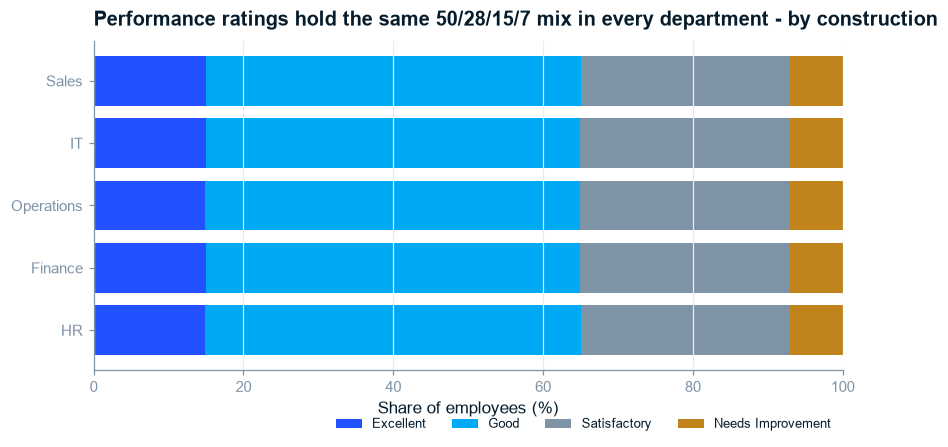

Performance_Rating
Good                50.00
Satisfactory        28.00
Excellent           15.00
Needs Improvement    7.00


In [7]:
RATINGS = ["Excellent","Good","Satisfactory","Needs Improvement"]
perf = (df.groupby(["Department","Performance_Rating"]).size()
          .unstack("Performance_Rating").reindex(index=DEPTS, columns=RATINGS))
perf_pct = perf.div(perf.sum(axis=1), axis=0)*100
colors = [mck_style.BLUE, mck_style.CYAN, mck_style.SLATE, mck_style.AMBER]
fig, ax = plt.subplots(figsize=(8,4.2))
left = np.zeros(len(DEPTS))
for r,col in zip(RATINGS, colors):
    ax.barh(DEPTS, perf_pct[r], left=left, color=col, label=r)
    left += perf_pct[r].values
ax.set_title("Performance ratings hold the same 50/28/15/7 mix in every department - by construction")
ax.set_xlabel("Share of employees (%)"); ax.invert_yaxis(); ax.set_xlim(0,100)
ax.legend(ncol=4, loc="lower right", bbox_to_anchor=(1,-0.22), fontsize=8.5)
ax.grid(axis="x"); ax.grid(axis="y", visible=False)
plt.savefig(f"{FIG}/fig5_performance.png", bbox_inches="tight"); plt.show()
print(df["Performance_Rating"].value_counts(normalize=True).mul(100).round(1).to_string())

> **So What:** the rating mix is essentially identical across departments — confirming ratings were
> **stratified-sampled** to preserve distribution, not earned. **Implication:** a model predicting rating from
> employee attributes has no real signal to learn (shown in notebook 04); use this cut to *validate* the
> sampling, not to rank departments on performance.

### Stage 3 — Gate checklist ✅
- [x] Five hypothesis-driven cuts (assessment §5), each mapped to a report Key Line
- [x] All titles are **action titles**; each exhibit has a **So What + Implication**
- [x] Figures exported to `reports/figures/` for the report
- [x] Rule-generated artifacts (clean pay ladder, flat attrition, uniform ratings) flagged, not oversold

→ Proceed to **04 · Analysis**.